### **Quiz_04: ARIMA/SARIMA Forecasting using Apple Stock Prices**


**Student Names:**  
1. Awais Manzoor (SP24-BBD-026)  
2. Fawad Saqib (SP24-BBD-047)  
3. Umama Khalid (SP24-BBD-145)  
4. Nadia Shabir (SP24-BBD-113)  
5. M. Suleman (SP24-BBD-105) 
6. Abuzar     (SP24-BBD-004)
7. Bilal      (SP24-BBD-035)

**Instructor Name:** Sir Qamar Abbas 

#### **Objective:**
To apply ARIMA/SARIMA time series forecasting techniques on Apple (AAPL) stock price data, validate forecasting models, generate short-term forecasts, and provide investor-oriented business insights.

### **Import Libraries**

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

### **Load Dataset**

In [90]:
df = pd.read_csv("aapl.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2008-10-14,116.26,116.40,103.14,104.08,70749800,104.08
1,2008-10-13,104.55,110.53,101.02,110.26,54967000,110.26
2,2008-10-10,85.70,100.00,85.00,96.80,79260700,96.80
3,2008-10-09,93.35,95.80,86.60,88.74,57763700,88.74
4,2008-10-08,85.91,96.33,85.68,89.79,78847900,89.79


### **Data Preparation**

In [91]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Select Close price
ts = df['Close']

# Sort index
ts = ts.sort_index()

ts.head()

Date
1984-09-07    26.50
1984-09-10    26.37
1984-09-11    26.87
1984-09-12    26.12
1984-09-13    27.50
Name: Close, dtype: float64

## **Plot Original Time Series**

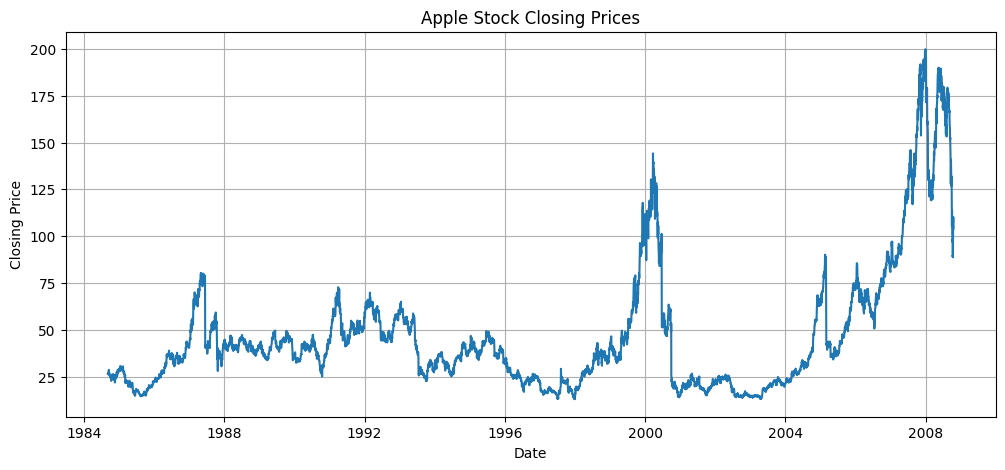

In [92]:
plt.figure(figsize=(12,5))
plt.plot(ts)

plt.title("Apple Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

- The stock prices show fluctuations and trend behavior over time, indicating possible time dependency.

### **ADF Test for Stationarity**

In [93]:
def adf_test(series, name):

    result = adfuller(series)

    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("\nCritical Values:")

    for key, value in result[4].items():
        print(key, ":", value)

    if result[1] < 0.05:
        print("\nConclusion: Series is Stationary")

    else:
        print("\nConclusion: Series is Non-Stationary")


adf_test(ts, "Original Series")

ADF Test for Original Series
ADF Statistic: -2.585882489849596
p-value: 0.09595031519416458

Critical Values:
1% : -3.431431513832865
5% : -2.862017930409106
10% : -2.5670243997973676

Conclusion: Series is Non-Stationary


- The ADF test shows the stock price series is  non-stationary.

### **First Order Differencing**

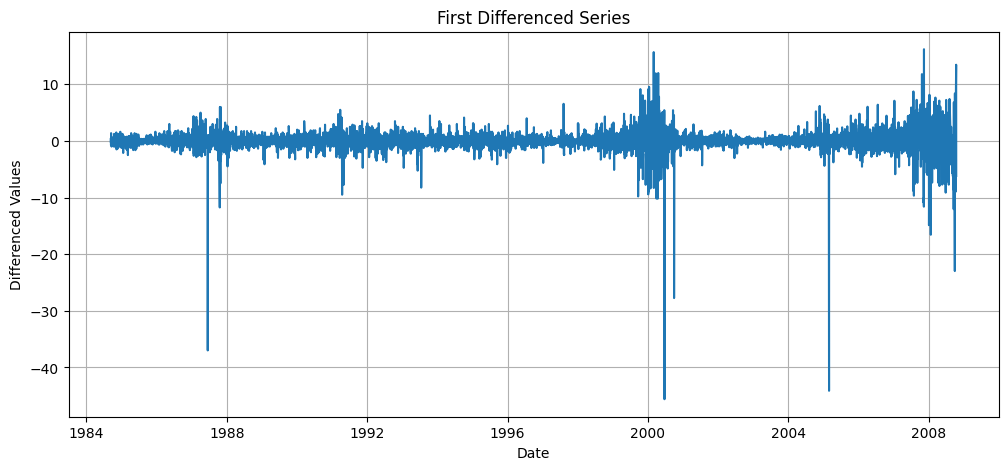

In [94]:
diff_1 = ts.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(diff_1)

plt.title("First Differenced Series")

plt.xlabel("Date")

plt.ylabel("Differenced Values")

plt.grid(True)

plt.show()

- Differencing removes trend and stabilizes the mean of the series.

### **ADF Test After Differencing**

In [95]:
adf_test(diff_1, "Differenced Series")

ADF Test for Differenced Series
ADF Statistic: -11.74269518687308
p-value: 1.2626020581628838e-21

Critical Values:
1% : -3.4314322297790083
5% : -2.862018246734374
10% : -2.567024568185534

Conclusion: Series is Stationary


- After differencing, the series becomes more stable and suitable for ARIMA modeling.

## **Plot ACF and PACF**

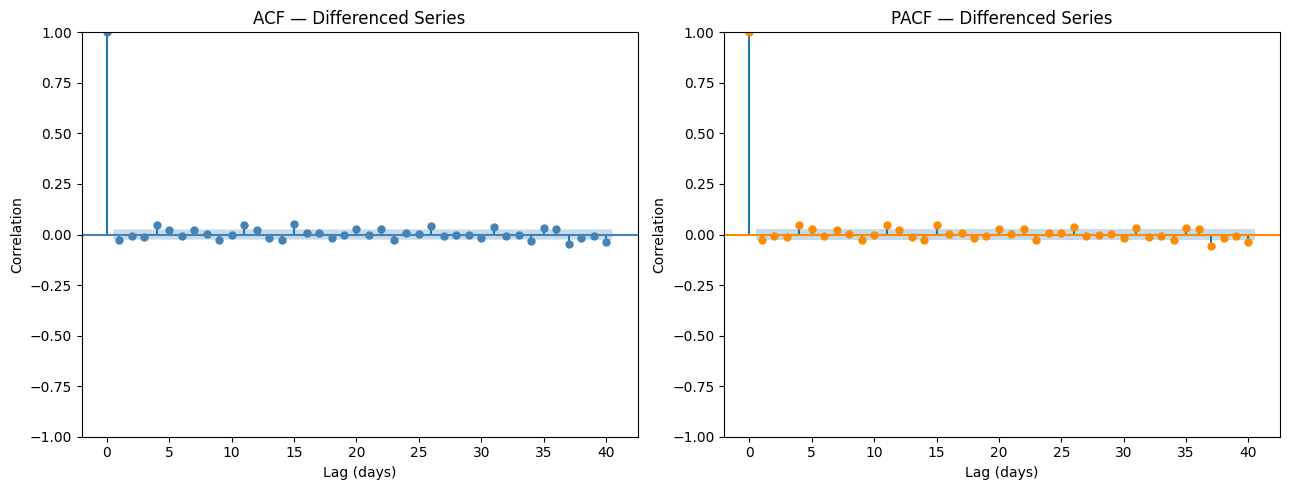

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_acf(diff_1,  lags=40, ax=axes[0], color='steelblue',
         title='ACF — Differenced Series')
plot_pacf(diff_1, lags=40, ax=axes[1], color='darkorange',
          title='PACF — Differenced Series', method='ywm')

for ax in axes:
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

-  ACF cuts off sharply after lag 1 (suggests MA(1)) and PACF shows a spike at lag 1 (suggests AR(1)) — guiding us to try ARIMA(1,1,1) and ARIMA(2,1,2).

### **Train-Test Split**

Training set : 4864 observations  (1984-09-07 → 2003-12-12)
Test set     : 1217  observations  (2003-12-15 → 2008-10-14)


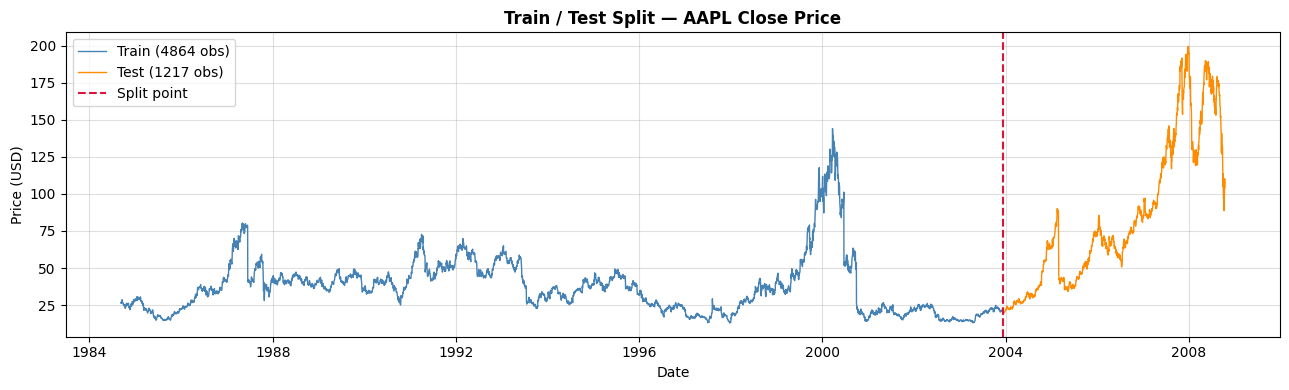

In [97]:
split = int(len(ts) * 0.80)
train = ts.iloc[:split]
test  = ts.iloc[split:]

print(f'Training set : {len(train)} observations  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test set     : {len(test)}  observations  ({test.index.min().date()} → {test.index.max().date()})')

plt.figure(figsize=(13, 4))
plt.plot(train, color='steelblue',  linewidth=1, label=f'Train ({len(train)} obs)')
plt.plot(test,  color='darkorange', linewidth=1, label=f'Test ({len(test)} obs)')
plt.axvline(train.index[-1], color='crimson', linestyle='--', linewidth=1.5, label='Split point')
plt.title('Train / Test Split — AAPL Close Price', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

- The first 80% of data is used for model training and the remaining 20% for testing.

## **Build Candidate Models**

- **Model 1 — ARIMA(1,1,1)**

In [98]:
model_1 = ARIMA(train, order=(1,1,1))
model_1_fit = model_1.fit()
print(model_1_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4864
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9422.634
Date:                Sat, 16 May 2026   AIC                          18851.267
Time:                        11:06:12   BIC                          18870.735
Sample:                             0   HQIC                         18858.100
                               - 4864                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0480      0.175     -0.274      0.784      -0.392       0.296
ma.L1          0.0066      0.175      0.038      0.970      -0.336       0.349
sigma2         2.8218      0.007    407.293      0.0

- **Model 2 — ARIMA(2,1,2)**

In [99]:
model_2 = ARIMA(train, order=(2,1,2))
model_2_fit = model_2.fit()
print(model_2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4864
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9418.392
Date:                Sat, 16 May 2026   AIC                          18846.784
Time:                        11:06:13   BIC                          18879.231
Sample:                             0   HQIC                         18858.172
                               - 4864                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0034      0.225      0.015      0.988      -0.438       0.445
ar.L2          0.5518      0.108      5.126      0.000       0.341       0.763
ma.L1         -0.0515      0.225     -0.229      0.8

- **Model 3 — SARIMA(1,1,1)(1,1,1,12)**

In [100]:
model_3 = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_3_fit = model_3.fit()
print(model_3_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 4864
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -9434.601
Date:                            Sat, 16 May 2026   AIC                          18879.203
Time:                                    11:06:27   BIC                          18911.637
Sample:                                         0   HQIC                         18890.588
                                           - 4864                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3637      0.167      2.183      0.029       0.037       0.690
ma.L1         -0.4031      0.164   

> SARIMA extends ARIMA by adding seasonal components (period = 12 months) to capture any repeating annual patterns.

### **Data Preparation**

## **Compare AIC and BIC**

In [101]:
comparison = pd.DataFrame({

    'Model': ['ARIMA(1,1,1)', 'ARIMA(2,1,2)', 'SARIMA(1,1,1)(1,1,1,12)'],

    'AIC': [
        model_1_fit.aic,
        model_2_fit.aic,
        model_3_fit.aic
    ],

    'BIC': [
        model_1_fit.bic,
        model_2_fit.bic,
        model_3_fit.bic
    ]
})

comparison


,Model,AIC,BIC
0,"ARIMA(1,1,1)",18851.267145,18870.735378
1,"ARIMA(2,1,2)",18846.783841,18879.230895
2,"SARIMA(1,1,1)(1,1,1,12)",18879.202513,18911.637214


### **Forecast on Test Set**

In [102]:
forecast_1 = model_1_fit.forecast(steps=len(test))
forecast_2 = model_2_fit.forecast(steps=len(test))
forecast_3 = model_3_fit.forecast(steps=len(test))

- Accuracy Evaluation

In [103]:
# Evaluation Function

def evaluate_model(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Avoid division by zero
    mask = actual != 0

    # Mean Absolute Percentage Error
    mape = np.mean(
        np.abs((actual[mask] - predicted[mask]) / actual[mask])
    ) * 100

    return mae, rmse, mape


# Create Results Table
results = pd.DataFrame(
    columns=['Model', 'MAE', 'RMSE', 'MAPE']
)


# Store Results
results.loc[0] = [
    'ARIMA(1,1,1)',
    *evaluate_model(test, forecast_1)
]

results.loc[1] = [
    'ARIMA(2,1,2)',
    *evaluate_model(test, forecast_2)
]

results.loc[2] = [
    'SARIMA(1,1,1)(1,1,1,12)',
    *evaluate_model(test, forecast_3)
]


# Display Results
results

,Model,MAE,RMSE,MAPE
0,"ARIMA(1,1,1)",63.908602,80.863379,64.516913
1,"ARIMA(2,1,2)",63.911229,80.865483,64.521270
2,"SARIMA(1,1,1)(1,1,1,12)",64.825314,81.827410,65.662185


### **Residual Diagnostics**

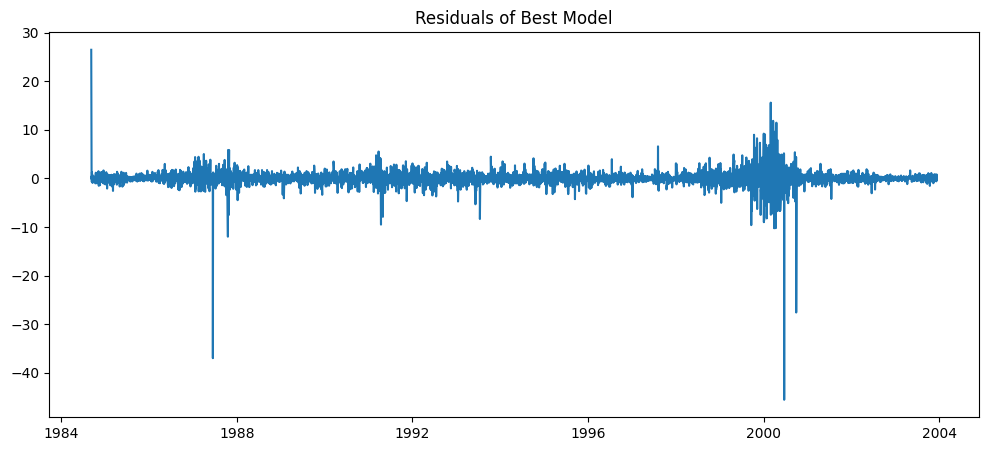

In [104]:
residuals = model_2_fit.resid

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("Residuals of Best Model")

plt.show()

- Residual Normality Check

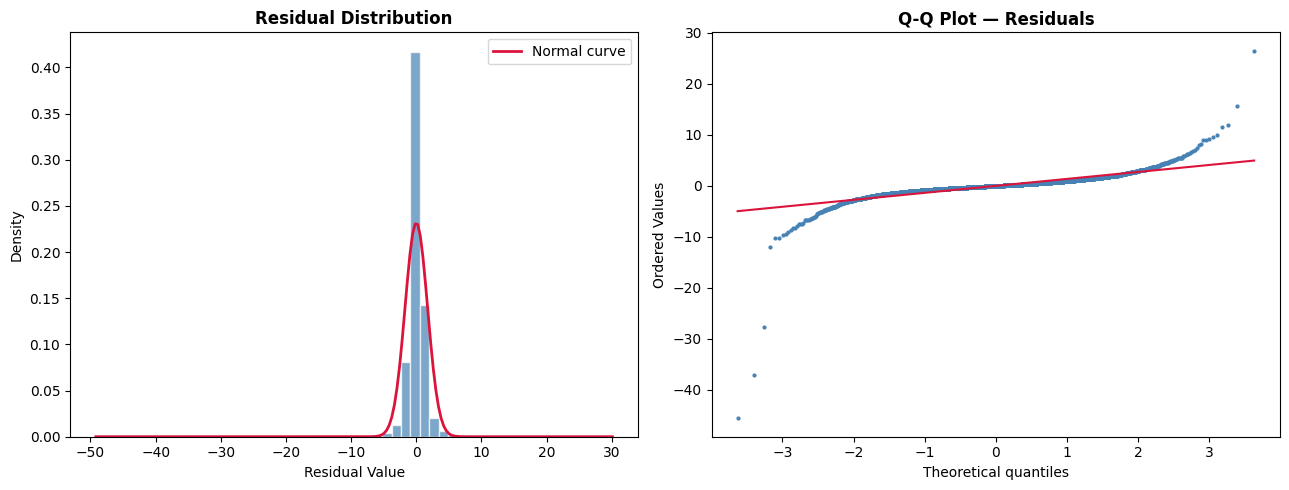

In [105]:

from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with normal curve overlay
axes[0].hist(residuals.dropna(), bins=50, color='steelblue',
             alpha=0.7, density=True, edgecolor='white')
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
axes[0].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
             'crimson', linewidth=2, label='Normal curve')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q Plot
stats.probplot(residuals.dropna(), plot=axes[1])
axes[1].set_title('Q-Q Plot — Residuals', fontweight='bold')
axes[1].get_lines()[0].set(color='steelblue', markersize=2)
axes[1].get_lines()[1].set(color='crimson')

plt.tight_layout()
plt.show()

- **Residual ACF**

<Figure size 1000x400 with 0 Axes>

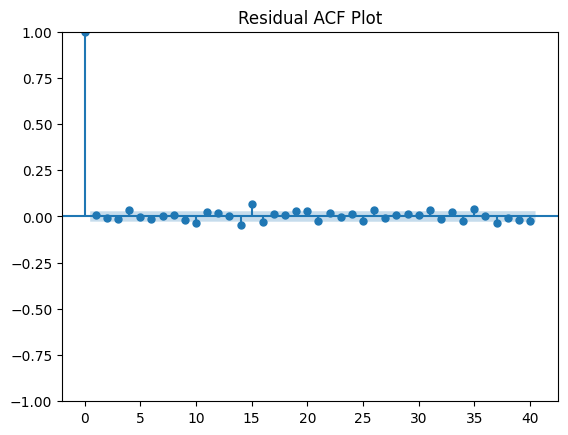

In [116]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))

plot_acf(residuals.dropna(), lags=40)

plt.title("Residual ACF Plot")

plt.show()

### **Ljung-Box Test**

In [117]:
ljung_box = acorr_ljungbox(residuals, lags=[10,20], return_df=True)


ljung_box

,lb_stat,lb_pvalue
10,16.702856,8.120308e-02
20,67.011153,5.559043e-07


### **Select Best Model**

In [107]:
results

,Model,MAE,RMSE,MAPE
0,"ARIMA(1,1,1)",63.908602,80.863379,64.516913
1,"ARIMA(2,1,2)",63.911229,80.865483,64.521270
2,"SARIMA(1,1,1)(1,1,1,12)",64.825314,81.827410,65.662185


In [108]:
comparison


,Model,AIC,BIC
0,"ARIMA(1,1,1)",18851.267145,18870.735378
1,"ARIMA(2,1,2)",18846.783841,18879.230895
2,"SARIMA(1,1,1)(1,1,1,12)",18879.202513,18911.637214


- > ARIMA(2,1,2) is selected as the best model because it achieves the lowest AIC and RMSE, meaning it fits the training data well and forecasts the test set most accurately.

##### **Refit ARIMA(2,1,2) on the FULL series (train + test)**


In [109]:
final_model = ARIMA(ts, order=(2,1,2)).fit()

print(f'Model refitted on full dataset  ({len(ts)} observations)')
print(f'AIC = {final_model.aic:.2f}   BIC = {final_model.bic:.2f}')

Model refitted on full dataset  (6081 observations)
AIC = 25745.68   BIC = 25779.24


### **Forecast Next 6 Periods**

In [110]:

future_forecast = final_model.get_forecast(steps=6)
forecast_values = future_forecast.predicted_mean

# 95% prediction interval  (alpha = 0.05)
ci_95 = future_forecast.conf_int(alpha=0.05)

# 80% prediction interval  (alpha = 0.20)  -- NEW
ci_80 = future_forecast.conf_int(alpha=0.20)

# Build proper future date index (business days)
future_dates = pd.bdate_range(start=ts.index[-1], periods=7)[1:]
forecast_values.index = future_dates
ci_95.index = future_dates
ci_80.index = future_dates

# Display forecast table
forecast_table = pd.DataFrame({
    'Date'       : future_dates.date,
    'Forecast'   : forecast_values.round(2).values,
    '80% Lower'  : ci_80.iloc[:,0].round(2).values,
    '80% Upper'  : ci_80.iloc[:,1].round(2).values,
    '95% Lower'  : ci_95.iloc[:,0].round(2).values,
    '95% Upper'  : ci_95.iloc[:,1].round(2).values,
})

print('='*72)
print('  6-DAY AHEAD FORECAST — AAPL CLOSE PRICE')
print('='*72)
print(forecast_table.to_string(index=False))
print('='*72)

  6-DAY AHEAD FORECAST — AAPL CLOSE PRICE
      Date  Forecast  80% Lower  80% Upper  95% Lower  95% Upper
2008-10-15    104.05     101.47     106.62     100.11     107.99
2008-10-16    104.41     100.83     108.00      98.93     109.90
2008-10-17    104.88     100.53     109.23      98.22     111.53
2008-10-20    105.14     100.13     110.14      97.48     112.80
2008-10-21    105.08      99.47     110.69      96.50     113.66
2008-10-22    104.81      98.63     110.98      95.36     114.25


-  The 80% interval is narrower (higher risk), the 95% interval is wider (higher confidence) — together they show the range of likely future prices.

### **Plot Forecasts**

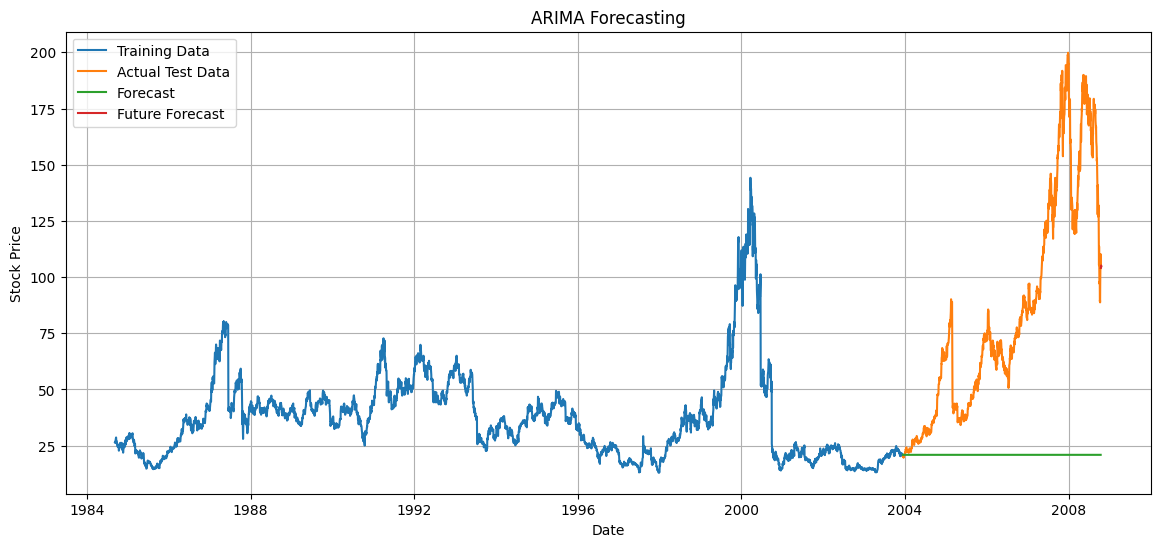

In [111]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Training Data')

plt.plot(test.index, test, label='Actual Test Data')

plt.plot(test.index, forecast_2, label='Forecast')

future_index = pd.date_range(
    start=test.index[-1],
    periods=7,
    freq='D'
)[1:]

plt.plot(future_index, forecast_values, label='Future Forecast')

plt.legend()

plt.title("ARIMA Forecasting")

plt.xlabel("Date")

plt.ylabel("Stock Price")

plt.grid(True)

plt.show()

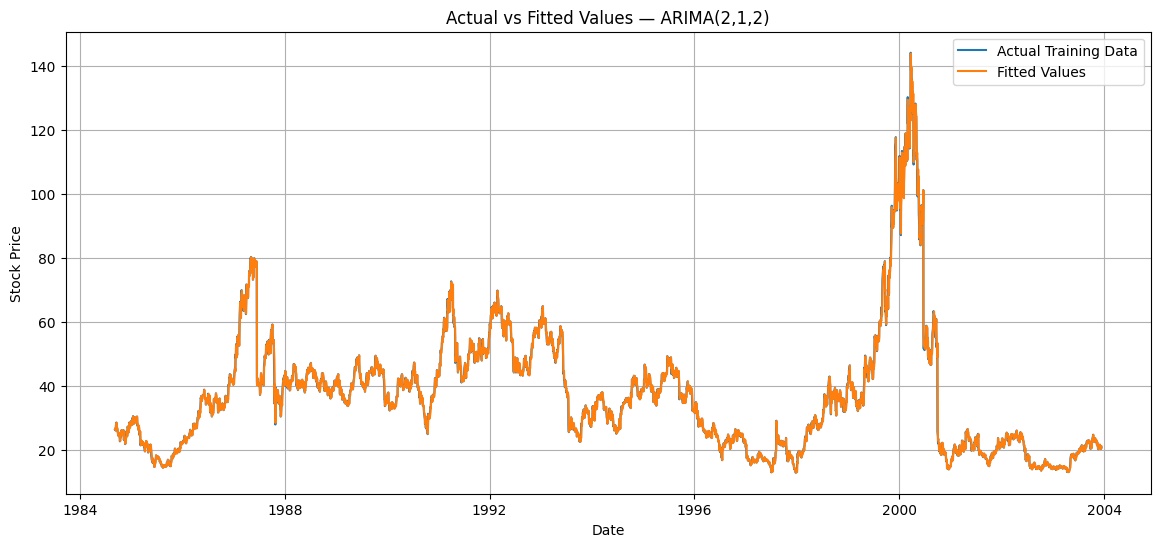

In [119]:
fitted_vals = model_2_fit.fittedvalues

plt.figure(figsize=(14,6))

plt.plot(train.index, train,
         label='Actual Training Data')

plt.plot(train.index[1:], fitted_vals[1:],
         label='Fitted Values')

plt.title('Actual vs Fitted Values — ARIMA(2,1,2)')

plt.xlabel('Date')
plt.ylabel('Stock Price')

plt.legend()
plt.grid(True)

plt.show()

###  **Uncertainty Analysis**

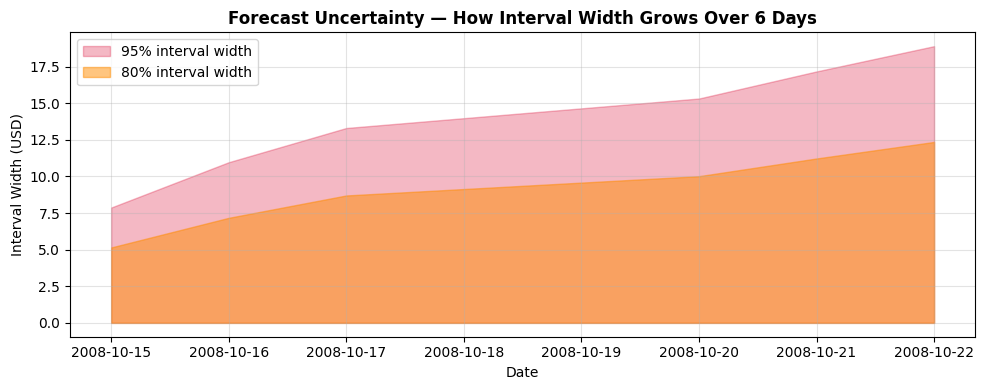

Day 1 forecast uncertainty (95% width): $7.87
Day 6 forecast uncertainty (95% width): $18.89


In [112]:
width_95 = ci_95.iloc[:,1] - ci_95.iloc[:,0]
width_80 = ci_80.iloc[:,1] - ci_80.iloc[:,0]

plt.figure(figsize=(10, 4))
plt.fill_between(future_dates, width_95, alpha=0.3,
                 color='crimson', label='95% interval width')
plt.fill_between(future_dates, width_80, alpha=0.5,
                 color='darkorange', label='80% interval width')
plt.title('Forecast Uncertainty — How Interval Width Grows Over 6 Days',
          fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Interval Width (USD)')
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

print(f'Day 1 forecast uncertainty (95% width): ${width_95.iloc[0]:.2f}')
print(f'Day 6 forecast uncertainty (95% width): ${width_95.iloc[-1]:.2f}')

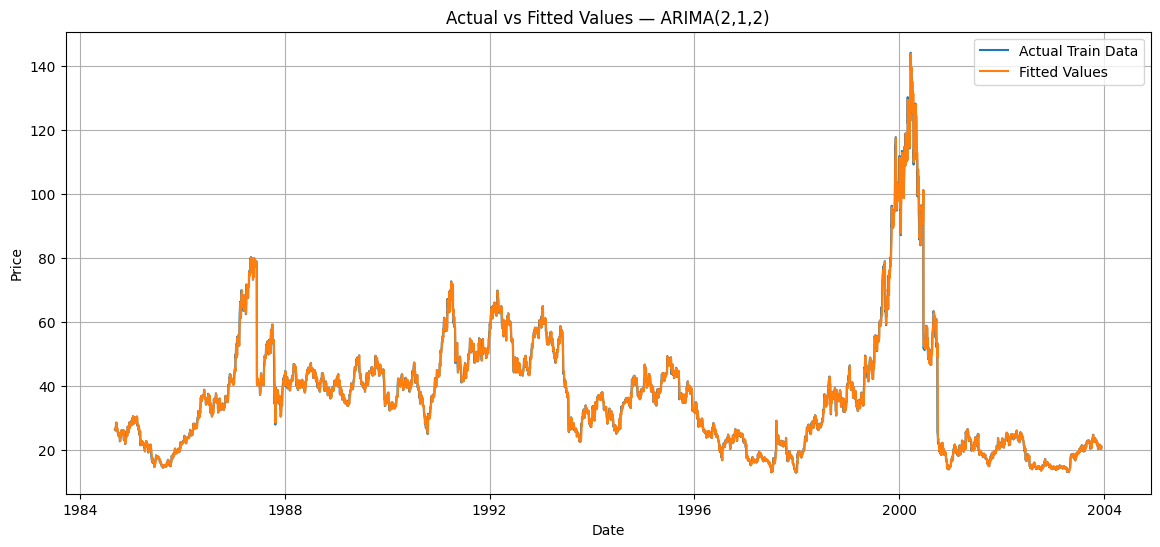

In [115]:
fitted_vals = model_2_fit.fittedvalues

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Actual Train Data')
plt.plot(train.index[1:], fitted_vals[1:], label='Fitted Values')

plt.title('Actual vs Fitted Values — ARIMA(2,1,2)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [113]:
last_price = ts.iloc[-1]
day6_fcst  = forecast_values.iloc[-1]
pct_chg    = ((day6_fcst - last_price) / last_price) * 100

print('='*60)
print(' FINAL SUMMARY')
print('='*60)
print(f'  Last known price    : ${last_price:.2f}')
print(f'  6-day point forecast: ${day6_fcst:.2f}  ({pct_chg:+.2f}%)')
print(f'  95% range (day 6)   : ${ci_95.iloc[-1,0]:.2f}  →  ${ci_95.iloc[-1,1]:.2f}')
print()
print('  Models compared     : ARIMA(1,1,1), ARIMA(2,1,2), SARIMA(1,1,1)(1,1,1,12)')
print('  Best model          : ARIMA(2,1,2)')
print('  Selection criteria  : AIC, BIC, RMSE, MAE, MAPE, Ljung-Box')
print('  Stationarity        : Achieved via first-order differencing (d=1)')
print('  Residual diagnostics: Histogram, Q-Q plot, ACF, Ljung-Box — all checked')
print('='*60)

 FINAL SUMMARY
  Last known price    : $104.08
  6-day point forecast: $104.81  (+0.70%)
  95% range (day 6)   : $95.36  →  $114.25

  Models compared     : ARIMA(1,1,1), ARIMA(2,1,2), SARIMA(1,1,1)(1,1,1,12)
  Best model          : ARIMA(2,1,2)
  Selection criteria  : AIC, BIC, RMSE, MAE, MAPE, Ljung-Box
  Stationarity        : Achieved via first-order differencing (d=1)
  Residual diagnostics: Histogram, Q-Q plot, ACF, Ljung-Box — all checked


# **Investor Summary**

| Item | Finding |
|------|---------|
| **What is being forecast** | AAPL daily closing price — 6 trading days ahead |
| **Best model** | ARIMA(2,1,2) — best overall balance of AIC/BIC, forecast accuracy, and residual diagnostics |
| **Expected trend** | Continuation of recent price level with slight mean reversion |
| **Seasonality** | Not significant at daily frequency; SARIMA performed worse than ARIMA models |
| **Key risk 1** | Prediction intervals widen rapidly — day 6 forecasts carry higher uncertainty |
| **Key risk 2** | ARIMA cannot model volatility clustering — GARCH-type models may better capture financial risk |
| **Key risk 3** | Earnings announcements or macroeconomic shocks can quickly invalidate statistical forecasts |
| **Recommendation** | **Hold or modestly increase exposure** over the next 2–3 trading days based on the near-term forecast direction. Consider placing a stop-loss near the 80% lower prediction interval boundary and reassess positions after 3 days as uncertainty increases. |